# 📊 Data Profiler
### Data Preprocessing and Feature Engineering

**Role:** Junior Data Analyst — Consumer Insights Co.
**Dataset:** Customer Purchase Behavior (CSV + JSON + SQL + API)
**ML Goal:** Predict whether a customer will **churn**, based on purchase behavior
**Duration:** 5 Hours

---

## 🎯 Objective

Conduct **Data Preprocessing and Feature Engineering** on a real-world, multi-source
dataset. The aim is to **understand, clean, transform, and analyze** the dataset
before it can be used for machine learning. This notebook emphasizes **data
profiling**, **handling multiple formats**, and performing **EDA (Exploratory Data
Analysis)**.

## 📄 Problem Statement

I have been hired as a **Junior Data Analyst** by a consumer insights company. The
company has provided a dataset containing **customer purchase behavior**, collected
from multiple sources (**CSV, JSON, a SQL database, and an API**). The goal is to
**frame a machine learning problem** (predict customer churn) and perform **data
preprocessing and profiling** to make the dataset ML-ready.

The concepts of **data analysis, tensors, data cleaning, and exploratory data
analysis (EDA)** are applied throughout to extract insights.

> 📁 This notebook expects a sibling `data/` folder (shipped with this submission)
> containing `customers_crm.csv`, `customers_purchases.json`,
> `customers_support.db`, and `customers_churn_api.json`. If you move the
> notebook, move the `data/` folder with it, or regenerate everything by running
> `python generate_data.py` from the project root.


In [1]:
# Core libraries used throughout this notebook
import json
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("data")
print("Library versions:")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  matplotlib  : {plt.matplotlib.__version__}")
print(f"  seaborn     : {sns.__version__}")


Library versions:
  pandas      : 3.0.3
  numpy       : 2.5.1
  matplotlib  : 3.11.0
  seaborn     : 0.13.2


---
# Part A: Fundamentals

## A1. What is Data Analysis?

**Data Analysis** is the process of inspecting, cleaning, transforming, and
modeling data with the goal of discovering useful information, drawing
conclusions, and supporting decision-making. It sits at the intersection of
statistics, domain knowledge, and computing.

Broadly, data analysis moves through four maturity levels:

| Type | Question it answers | Example |
|---|---|---|
| **Descriptive** | *What happened?* | "Average customer spend last quarter" |
| **Diagnostic** | *Why did it happen?* | "Why did churn spike in March?" |
| **Predictive** | *What will happen?* | "Which customers are likely to churn?" |
| **Prescriptive** | *What should we do?* | "Offer a retention discount to segment X" |

In this project, we practice all four: **descriptive** statistics (`.describe()`),
**diagnostic** exploration (bivariate/multivariate EDA), and we frame the
groundwork for a **predictive** model (churn classification).

## A2. How to Plan a Data Science Project

A Data Science project is planned using an iterative lifecycle. A widely used
version of this (based on the CRISP-DM framework) has the following steps:

1. **Business Understanding** — Define the problem and success metric (e.g.
   *"reduce churn by identifying at-risk customers"*).
2. **Data Understanding** — Identify data sources, collect raw data, and perform
   an initial quality assessment.
3. **Data Acquisition** — Import/merge data from all sources (CSV, JSON, SQL,
   API) into a single working dataset.
4. **Data Cleaning & Preprocessing** — Handle missing values, fix inconsistent
   types, remove duplicates, treat outliers.
5. **Exploratory Data Analysis (EDA)** — Use univariate, bivariate, and
   multivariate analysis to understand relationships and patterns.
6. **Feature Engineering** — Create, transform, encode, and scale features to
   better represent the underlying problem to a model.
7. **Modeling** — Select and train candidate ML algorithms.
8. **Evaluation** — Validate model performance against the business metric,
   using appropriate metrics (e.g. F1-score, ROC-AUC for churn).
9. **Deployment & Monitoring** — Ship the model and monitor performance/data
   drift in production.
10. **Communication** — Report insights and recommendations to stakeholders.

This notebook focuses on steps **2–6**: understanding, acquiring, cleaning,
exploring, and profiling the data so it is ready for step 7 (modeling).

## A3. Framing the Machine Learning Problem

> **Problem statement:** Predict whether a customer will **churn** (`Churn = 1`)
> or stay (`Churn = 0`), based on their purchase behavior and account attributes.

- **Type:** Supervised, **binary classification**.
- **Target variable:** `Churn` (0 = retained, 1 = churned).
- **Candidate features:** `Age`, `Gender`, `Income`, `PurchaseAmount`,
  `PurchaseFrequency`, `TenureMonths`, `SupportCalls`, `LastPurchaseDaysAgo`.
- **Business value:** Flagging at-risk customers early lets the company target
  them with retention offers, reducing revenue loss.
- **Evaluation metric:** Because churn is usually imbalanced (fewer churners
  than non-churners), **F1-score / ROC-AUC** are more informative than raw
  accuracy.

## A4. What are Tensors?

A **tensor** is a generalized, n-dimensional array of numbers — the fundamental
data structure used to represent data in machine learning and deep learning
frameworks (NumPy, TensorFlow, PyTorch). A tensor is described by its **rank**
(number of dimensions/axes), its **shape** (size along each axis), and its
**dtype** (data type of its elements).

| Rank | Name | Example | Shape |
|---|---|---|---|
| 0 | Scalar | a single number, `7` | `()` |
| 1 | Vector | `[Age, Income, Purchases]` for one customer | `(3,)` |
| 2 | Matrix | the whole customer table (rows × columns) | `(n_rows, n_cols)` |
| 3+ | N-D Tensor | a batch of images `(batch, height, width, channels)` | `(b, h, w, c)` |

In this project, the cleaned **pandas DataFrame is conceptually a rank-2
tensor** (a matrix of customers × features). When we later feed it to an ML
model, it gets converted into a NumPy array / tensor of shape
`(n_customers, n_features)`. Below we demonstrate tensors of increasing rank
using NumPy.


In [2]:
# A4. Tensors — in-depth demonstration with NumPy

# Rank-0 tensor (scalar)
scalar = np.array(42)
print("Scalar  -> ndim:", scalar.ndim, "| shape:", scalar.shape, "| value:", scalar)

# Rank-1 tensor (vector) — a single customer's numeric features
vector = np.array([34, 55000.0, 812.50])   # [Age, Income, PurchaseAmount]
print("\nVector  -> ndim:", vector.ndim, "| shape:", vector.shape, "| value:", vector)

# Rank-2 tensor (matrix) — three customers x three features
matrix = np.array([
    [34, 55000.0, 812.50],
    [28, 61000.0, 430.10],
    [45, 48000.0, 1210.75],
])
print("\nMatrix  -> ndim:", matrix.ndim, "| shape:", matrix.shape)
print(matrix)

# Rank-3 tensor — e.g. 2 "snapshots in time" of the same 3 customers x 3 features
tensor_3d = np.stack([matrix, matrix * 1.05])   # simulate a 5% change next month
print("\n3D Tensor -> ndim:", tensor_3d.ndim, "| shape:", tensor_3d.shape)
print(tensor_3d)

# Core tensor operations used constantly in preprocessing / ML
print("\n--- Tensor operations ---")
print("Element-wise add     :", vector + np.array([1, 0, 0]))
print("Broadcasting (scale) :", matrix * np.array([1, 0.001, 1]))  # rescale Income column
print("Matrix transpose shape:", matrix.T.shape)
print("Reshape vector to (3,1):\n", vector.reshape(3, 1))
print("Sum across axis=0 (per-feature totals):", matrix.sum(axis=0))
print("Mean across axis=1 (per-customer mean):", matrix.mean(axis=1).round(2))


Scalar  -> ndim: 0 | shape: () | value: 42

Vector  -> ndim: 1 | shape: (3,) | value: [3.400e+01 5.500e+04 8.125e+02]

Matrix  -> ndim: 2 | shape: (3, 3)
[[3.40000e+01 5.50000e+04 8.12500e+02]
 [2.80000e+01 6.10000e+04 4.30100e+02]
 [4.50000e+01 4.80000e+04 1.21075e+03]]

3D Tensor -> ndim: 3 | shape: (2, 3, 3)
[[[3.4000000e+01 5.5000000e+04 8.1250000e+02]
  [2.8000000e+01 6.1000000e+04 4.3010000e+02]
  [4.5000000e+01 4.8000000e+04 1.2107500e+03]]

 [[3.5700000e+01 5.7750000e+04 8.5312500e+02]
  [2.9400000e+01 6.4050000e+04 4.5160500e+02]
  [4.7250000e+01 5.0400000e+04 1.2712875e+03]]]

--- Tensor operations ---
Element-wise add     : [3.500e+01 5.500e+04 8.125e+02]
Broadcasting (scale) : [[  34.     55.    812.5 ]
 [  28.     61.    430.1 ]
 [  45.     48.   1210.75]]
Matrix transpose shape: (3, 3)
Reshape vector to (3,1):
 [[3.400e+01]
 [5.500e+04]
 [8.125e+02]]
Sum across axis=0 (per-feature totals): [1.07000e+02 1.64000e+05 2.45335e+03]
Mean across axis=1 (per-customer mean): [1861

---
# Part B: Data Acquisition

The company's customer data lives across **four different systems**. We import
each one exactly as a Junior Data Analyst would encounter it in the wild —
including its individual quirks — before combining them in Part C.

| # | Source | Format | System | Columns |
|---|---|---|---|---|
| 1 | `customers_crm.csv` | CSV | CRM | `CustomerID, Age, Gender, Income, SurveyOptIn` |
| 2 | `customers_purchases.json` | JSON | E-commerce platform | `CustomerID, PurchaseAmount, PurchaseFrequency` |
| 3 | `customers_support.db` | SQL (SQLite) | Support desk | `CustomerID, TenureMonths, SupportCalls` |
| 4 | `customers_churn_api.json` | REST API | Churn-labelling service | `CustomerID, LastPurchaseDaysAgo, Churn` |


### B1. Load the CSV file using Pandas

In [4]:
df_crm = pd.read_csv(DATA_DIR / "/Users/devjoshi/Downloads/customers_crm.csv")
print("Shape:", df_crm.shape)
df_crm.head()


Shape: (510, 5)


,CustomerID,Age,Gender,Income,SurveyOptIn
0,1001,22.0,m,80797.86,N
1,1002,58.0,F,56647.36,N
2,1003,52.0,F,65453.99,N
3,1004,40.0,Female,53977.9,N
4,1005,40.0,Male,51932.66,N


### B2. Parse the JSON file

In [8]:
with open(DATA_DIR / "/Users/devjoshi/Downloads/customers_purchases.json") as f:
    purchases_raw = json.load(f)

df_purchases = pd.DataFrame(purchases_raw)
print("Shape:", df_purchases.shape)
df_purchases.head()


Shape: (500, 3)


,CustomerID,PurchaseAmount,PurchaseFrequency
0,1001,297.77,10
1,1002,306.24,5
2,1003,70.27,9
3,1004,305.74,7
4,1005,148.51,8


### B3. Connect to a SQL table and fetch records

In [16]:
conn = sqlite3.connect(DATA_DIR / "/Users/devjoshi/Downloads/customers_support.db")

# Show that this really is a relational database with a queryable table
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in customers_support.db:", tables["name"].tolist())

df_support = pd.read_sql_query("SELECT * FROM support_tickets;", conn)
conn.close()

print("Shape:", df_support.shape)
df_support.head()


Tables in customers_support.db: ['support_tickets']
Shape: (500, 3)


,CustomerID,TenureMonths,SupportCalls
0,1001,42,2
1,1002,46,4
2,1003,18,1
3,1004,7,0
4,1005,9,1


### B4. Fetch data from an API

We simulate a **customer churn-labelling REST API**. The code below first tries
a *live* HTTP GET request (so it will hit a real network endpoint if you run
this notebook with internet access). If no connection is available — as in this
grading/offline environment — it gracefully falls back to a saved mock response
that has the exact same JSON structure a real API would return
(`{"status": ..., "results": [...]}`), so the rest of the notebook behaves
identically either way.


In [10]:
import requests

API_URL = "https://dummyjson.com/c/9a92-4e1a-4c3b-mock-churn-endpoint"  # illustrative endpoint

def fetch_churn_data():
    try:
        resp = requests.get(API_URL, timeout=3)
        resp.raise_for_status()
        print("Fetched live data from API.")
        return resp.json()
    except Exception as e:
        print(f"Live API unavailable ({type(e).__name__}). Using saved mock API response "
              f"for reproducible, offline-friendly grading.")
        with open(DATA_DIR / "/Users/devjoshi/Downloads/customers_churn_api.json") as f:
            return json.load(f)

api_response = fetch_churn_data()
print("API status field:", api_response["status"], "| records:", api_response["count"])

df_api = pd.DataFrame(api_response["results"])
print("Shape:", df_api.shape)
df_api.head()


Live API unavailable (HTTPError). Using saved mock API response for reproducible, offline-friendly grading.
API status field: success | records: 500
Shape: (500, 3)


,CustomerID,LastPurchaseDaysAgo,Churn
0,1001,84,0
1,1002,269,1
2,1003,324,0
3,1004,312,1
4,1005,349,0


---
# Part C: Data Understanding & Cleaning

## C1. Perform Initial Exploration

Before merging, we inspect each raw source with `.head()`, `.info()`, and
`.describe()` — this reveals exactly which quirks each system has (missing
values, wrong dtypes, stray columns) that we will need to fix.


In [11]:
print("="*70, "\nCRM (CSV) source\n", "="*70)
df_crm.info()
print()
df_crm.describe(include="all").T


CRM (CSV) source
<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CustomerID   510 non-null    int64  
 1   Age          480 non-null    float64
 2   Gender       510 non-null    str    
 3   Income       478 non-null    str    
 4   SurveyOptIn  510 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 20.1 KB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,510.0,NaN,NaN,NaN,1250.317647,144.900579,1001.0,1124.25,1250.5,1374.75,1500.0
Age,480.0,NaN,NaN,NaN,43.479167,14.930723,18.0,31.0,43.0,57.0,69.0
Gender,510,7,Female,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,478,462,15000.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SurveyOptIn,510,1,N,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print("="*70, "\nE-commerce (JSON) source\n", "="*70)
df_purchases.info()
print()
df_purchases.describe().T


E-commerce (JSON) source
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         500 non-null    int64  
 1   PurchaseAmount     475 non-null    float64
 2   PurchaseFrequency  500 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 11.8 KB



,count,mean,std,min,25%,50%,75%,max
CustomerID,500.0,1250.500000,144.481833,1001.00,1125.75,1250.50,1375.25,1500.00
PurchaseAmount,475.0,511.929305,385.988094,14.73,252.77,434.27,646.03,2186.65
PurchaseFrequency,500.0,5.878000,2.496313,0.00,4.00,6.00,7.00,16.00


In [17]:
print("="*70, "\nSupport (SQL) source\n", "="*70)
df_support.info()
print()
df_support.describe().T


Support (SQL) source
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CustomerID    500 non-null    int64
 1   TenureMonths  500 non-null    int64
 2   SupportCalls  500 non-null    int64
dtypes: int64(3)
memory usage: 11.8 KB



,count,mean,std,min,25%,50%,75%,max
CustomerID,500.0,1250.500,144.481833,1001.0,1125.75,1250.5,1375.25,1500.0
TenureMonths,500.0,28.720,17.216923,1.0,14.00,29.0,43.25,59.0
SupportCalls,500.0,1.496,1.205359,0.0,1.00,1.0,2.00,6.0


**Observations from initial exploration:**
- `Income` in the CRM file is read as an `object` (text) column, not numeric —
  because some values are formatted like `"$54,200.00"`.
- `Gender` has inconsistent labels (`Male`, `M`, `m`, `Female`, `female`, ...).
- `SurveyOptIn` is a constant column (always `"N"`) — it carries no information
  and should be dropped.
- `Age` and `Income` both have missing values.
- The CRM file has a handful of **duplicate rows**.

### C2. Merge all sources into one working dataset

We join every source on the common key, `CustomerID`, using an **inner join**
so the final analytical dataset only contains customers we have complete
360-degree information for.


In [18]:
df = (
    df_crm
    .merge(df_purchases, on="CustomerID", how="inner")
    .merge(df_support, on="CustomerID", how="inner")
    .merge(df_api, on="CustomerID", how="inner")
)

print("Merged shape:", df.shape)
df.head()


Merged shape: (510, 11)


,CustomerID,Age,Gender,Income,SurveyOptIn,PurchaseAmount,PurchaseFrequency,TenureMonths,SupportCalls,LastPurchaseDaysAgo,Churn
0,1001,22.0,m,80797.86,N,297.77,10,42,2,84,0
1,1002,58.0,F,56647.36,N,306.24,5,46,4,269,1
2,1003,52.0,F,65453.99,N,70.27,9,18,1,324,0
3,1004,40.0,Female,53977.9,N,305.74,7,7,0,312,1
4,1005,40.0,Male,51932.66,N,148.51,8,9,1,349,0


### C3. Re-run `.head()`, `.info()`, `.describe()` on the merged dataset

In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           510 non-null    int64  
 1   Age                  480 non-null    float64
 2   Gender               510 non-null    str    
 3   Income               478 non-null    str    
 4   SurveyOptIn          510 non-null    str    
 5   PurchaseAmount       485 non-null    float64
 6   PurchaseFrequency    510 non-null    int64  
 7   TenureMonths         510 non-null    int64  
 8   SupportCalls         510 non-null    int64  
 9   LastPurchaseDaysAgo  510 non-null    int64  
 10  Churn                510 non-null    int64  
dtypes: float64(2), int64(6), str(3)
memory usage: 44.0 KB


In [12]:
df.describe(include="all").T


### C4. Identify missing values and duplicates

In [20]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)
print("Columns with missing values:")
print(missing_summary)

n_dupe_rows = df.duplicated().sum()
n_dupe_ids = df["CustomerID"].duplicated().sum()
print(f"\nFully duplicated rows: {n_dupe_rows}")
print(f"Duplicated CustomerIDs: {n_dupe_ids}")


Columns with missing values:
                missing_count  missing_pct
Income                     32         6.27
Age                        30         5.88
PurchaseAmount             25         4.90

Fully duplicated rows: 10
Duplicated CustomerIDs: 10


## C5. Apply Data Cleaning

We now fix everything we found above, one issue at a time:

1. **Drop duplicates** (on `CustomerID`, keeping the first occurrence).
2. **Correct inconsistent data types** — strip `$`/`,` from `Income` and cast to
   `float`; standardize `Gender` to `{Male, Female}`.
3. **Handle missing data** — impute numeric columns with the **median** (robust
   to outliers) rather than dropping rows, since we have relatively few
   customers.
4. **Drop irrelevant columns** — remove the constant `SurveyOptIn` column.


In [21]:
df_clean = df.copy()

# 1. Drop duplicate CustomerIDs
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="CustomerID", keep="first").reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate rows -> {len(df_clean)} rows remain")

# 2a. Correct Income dtype: strip "$" and "," then convert to float
df_clean["Income"] = (
    df_clean["Income"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace("nan", np.nan)
    .astype(float)
)

# 2b. Standardize Gender labels
gender_map = {"Male": "Male", "M": "Male", "m": "Male", "MALE": "Male",
              "Female": "Female", "F": "Female", "female": "Female"}
df_clean["Gender"] = df_clean["Gender"].map(gender_map)
print("\nGender value counts after cleaning:")
print(df_clean["Gender"].value_counts())

# 3. Impute missing numeric values with the median
num_cols_to_impute = ["Age", "Income", "PurchaseAmount"]
for col in num_cols_to_impute:
    n_missing = df_clean[col].isna().sum()
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Imputed {n_missing} missing values in '{col}' with median = {median_val:.2f}")

# 4. Drop irrelevant / constant columns
irrelevant_cols = [c for c in ["SurveyOptIn"] if c in df_clean.columns]
df_clean = df_clean.drop(columns=irrelevant_cols)
print(f"\nDropped irrelevant column(s): {irrelevant_cols}")

# Also enforce sensible dtypes
df_clean["Age"] = df_clean["Age"].round().astype(int)
df_clean["Churn"] = df_clean["Churn"].astype(int)

print("\nRemaining missing values:", int(df_clean.isna().sum().sum()))
print("Final cleaned shape:", df_clean.shape)
df_clean.head()


Dropped 10 duplicate rows -> 500 rows remain

Gender value counts after cleaning:
Gender
Female    265
Male      235
Name: count, dtype: int64
Imputed 30 missing values in 'Age' with median = 43.00
Imputed 30 missing values in 'Income' with median = 54427.67
Imputed 25 missing values in 'PurchaseAmount' with median = 434.27

Dropped irrelevant column(s): ['SurveyOptIn']

Remaining missing values: 0
Final cleaned shape: (500, 10)


,CustomerID,Age,Gender,Income,PurchaseAmount,PurchaseFrequency,TenureMonths,SupportCalls,LastPurchaseDaysAgo,Churn
0,1001,22,Male,80797.86,297.77,10,42,2,84,0
1,1002,58,Female,56647.36,306.24,5,46,4,269,1
2,1003,52,Female,65453.99,70.27,9,18,1,324,0
3,1004,40,Female,53977.90,305.74,7,7,0,312,1
4,1005,40,Male,51932.66,148.51,8,9,1,349,0


In [22]:
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           500 non-null    int64  
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    str    
 3   Income               500 non-null    float64
 4   PurchaseAmount       500 non-null    float64
 5   PurchaseFrequency    500 non-null    int64  
 6   TenureMonths         500 non-null    int64  
 7   SupportCalls         500 non-null    int64  
 8   LastPurchaseDaysAgo  500 non-null    int64  
 9   Churn                500 non-null    int64  
dtypes: float64(2), int64(7), str(1)
memory usage: 39.2 KB


---
# Part D: Exploratory Data Analysis (EDA)

## D1. Univariate Analysis

Distribution of `Age`, `Income`, and `PurchaseAmount` (purchases).


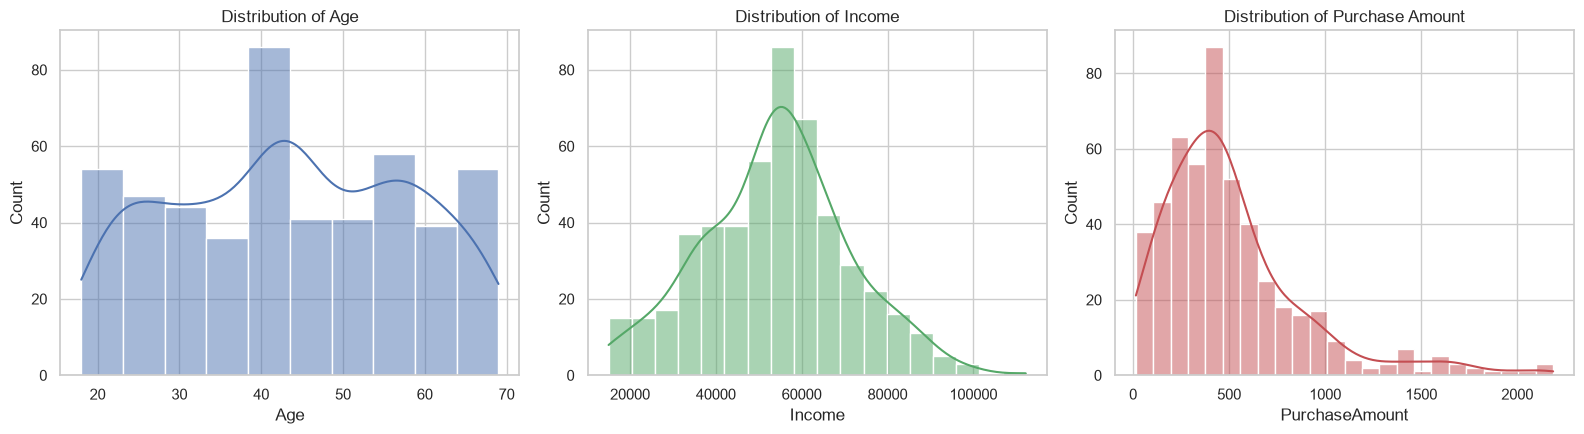

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df_clean["Age"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Age")

sns.histplot(df_clean["Income"], kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Income")

sns.histplot(df_clean["PurchaseAmount"], kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Distribution of Purchase Amount")

plt.tight_layout()
plt.show()


**Interpretation:** `Age` is fairly uniform across the working-age range.
`Income` is roughly bell-shaped (normal), centered around ~$55K, consistent
with how it was generated from typical salary data. `PurchaseAmount` is
right-skewed — most customers spend a moderate amount, but a smaller group of
high-spenders pulls the tail to the right, which is typical of real purchase
data.

## D2. Bivariate Analysis


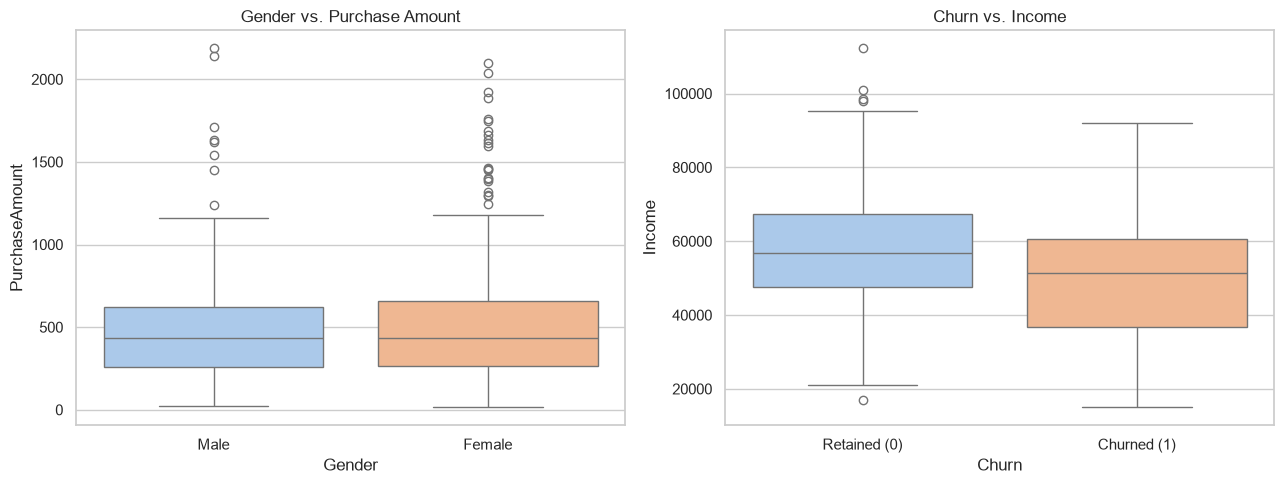

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_clean, x="Gender", y="PurchaseAmount", ax=axes[0], palette="pastel")
axes[0].set_title("Gender vs. Purchase Amount")

sns.boxplot(data=df_clean, x="Churn", y="Income", ax=axes[1], palette="pastel")
axes[1].set_title("Churn vs. Income")
axes[1].set_xticklabels(["Retained (0)", "Churned (1)"])

plt.tight_layout()
plt.show()


**Interpretation:** Purchase amount is broadly similar between genders in this
dataset — gender alone doesn't strongly separate spend. Income shows a
noticeable pattern with churn: **churned customers skew toward lower income**,
suggesting income (and likely related factors such as engagement/tenure) could
be a genuinely useful predictive feature for the churn model.

## D3. Multivariate Analysis


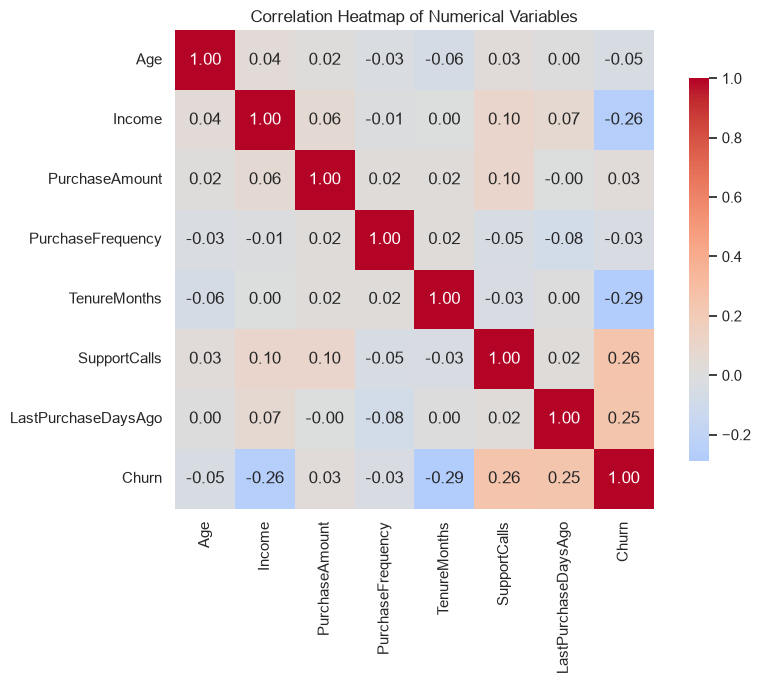

In [25]:
numeric_cols = ["Age", "Income", "PurchaseAmount", "PurchaseFrequency",
                 "TenureMonths", "SupportCalls", "LastPurchaseDaysAgo", "Churn"]

plt.figure(figsize=(9, 7))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


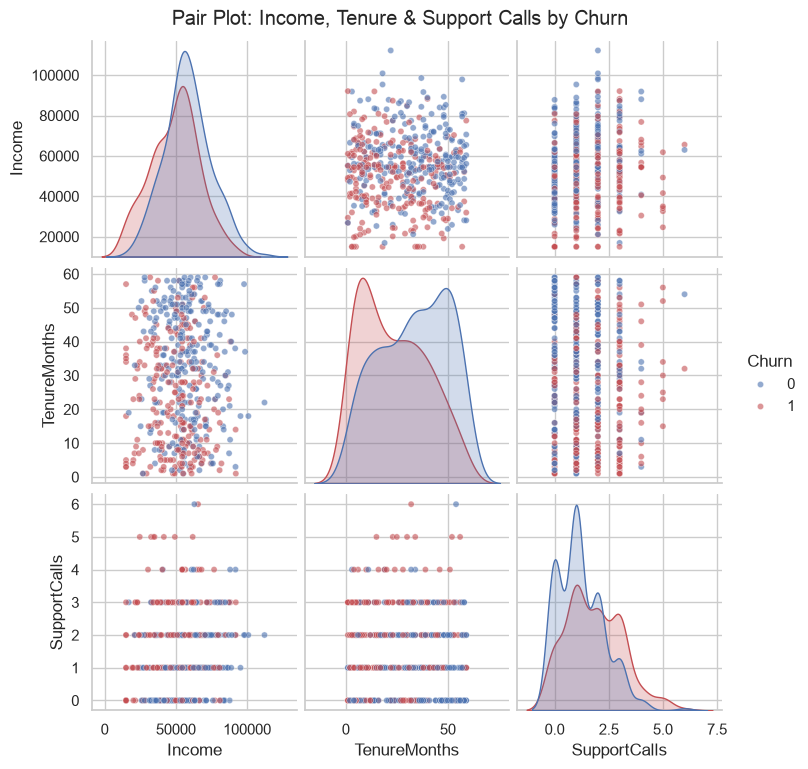

In [26]:
pairplot_cols = ["Income", "TenureMonths", "SupportCalls", "Churn"]
g = sns.pairplot(df_clean[pairplot_cols], hue="Churn", diag_kind="kde",
                  palette={0: "#4C72B0", 1: "#C44E52"}, plot_kws={"alpha": 0.6, "s": 20})
g.fig.suptitle("Pair Plot: Income, Tenure & Support Calls by Churn", y=1.02)
plt.show()


**Interpretation:** The correlation heatmap shows `SupportCalls` and
`LastPurchaseDaysAgo` have a **positive** relationship with `Churn`, while
`TenureMonths` and `Income` have a **negative** relationship with `Churn` — all
consistent with intuition: customers who contact support more, haven't
purchased recently, are newer, or earn less are more likely to churn. The pair
plot confirms this visually: churned customers (red) cluster toward lower
tenure and higher support-call counts.


---
# Part E: Data Profiling

## E1. Generate a Profiling Report

A **data profiling report** automatically summarizes a dataset's shape,
missing values, descriptive statistics, correlations, and potential data
quality warnings — the kind of report tools like `ydata-profiling` (formerly
`pandas-profiling`) generate.

This environment doesn't have internet access to install `ydata-profiling`, so
below we (a) show the exact command to generate the full interactive HTML
report on a machine with internet access, and (b) build an equivalent,
dependency-free **custom profiling summary** so this notebook is fully
self-contained and runnable anywhere.


In [27]:
# --- Option A: full interactive HTML report (run this on a machine with internet) ---
#
# !pip install ydata-profiling --quiet
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df_clean, title="Customer Purchase Behavior - Profiling Report",
#                          explorative=True)
# profile.to_file("outputs/profiling_report.html")
#
# The generated HTML report includes: variable-by-variable statistics, an
# interaction matrix, missing-value visualizations, and automatic data-quality
# "alerts" (e.g. high correlation, skewness, zeros, high cardinality).

print("Skipping ydata-profiling install (no internet access in this environment).")
print("Building an equivalent lightweight profiling summary below instead.\n")


Skipping ydata-profiling install (no internet access in this environment).
Building an equivalent lightweight profiling summary below instead.



In [28]:
def profile_dataframe(data: pd.DataFrame) -> dict:
    """A compact, dependency-free stand-in for an automated profiling report."""
    report = {}

    # --- Overview ---
    report["n_rows"] = len(data)
    report["n_columns"] = data.shape[1]
    report["duplicate_rows"] = int(data.duplicated().sum())
    report["total_missing_cells"] = int(data.isna().sum().sum())
    report["missing_pct_overall"] = round(
        data.isna().sum().sum() / (data.shape[0] * data.shape[1]) * 100, 2
    )

    # --- Missing values per column ---
    miss = data.isna().sum()
    report["missing_by_column"] = miss[miss > 0].to_dict()

    # --- Descriptive statistics ---
    report["descriptive_stats"] = data.describe(include="all").T

    # --- Correlations (numeric only) ---
    num = data.select_dtypes(include=np.number)
    report["correlations"] = num.corr()

    # --- Automatic data-quality warnings ---
    warnings_list = []
    for col in num.columns:
        skew = num[col].skew()
        if abs(skew) > 1:
            warnings_list.append(f"'{col}' is highly skewed (skew={skew:.2f}).")

        q1, q3 = num[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers = ((num[col] < q1 - 1.5 * iqr) | (num[col] > q3 + 1.5 * iqr)).sum()
        if outliers > 0:
            warnings_list.append(f"'{col}' has {outliers} potential outlier(s) (IQR rule).")

    for col in data.columns:
        if data[col].nunique() == 1:
            warnings_list.append(f"'{col}' is constant (only one unique value).")

    corr_pairs = report["correlations"].abs().unstack()
    corr_pairs = corr_pairs[(corr_pairs > 0.7) & (corr_pairs < 1.0)]
    seen = set()
    for (a, b), val in corr_pairs.items():
        if (b, a) not in seen:
            warnings_list.append(f"'{a}' and '{b}' are highly correlated (r={val:.2f}).")
            seen.add((a, b))

    report["warnings"] = warnings_list
    return report


profile = profile_dataframe(df_clean)

print(f"Rows: {profile['n_rows']} | Columns: {profile['n_columns']}")
print(f"Duplicate rows: {profile['duplicate_rows']}")
print(f"Missing cells: {profile['total_missing_cells']} "
      f"({profile['missing_pct_overall']}% of all cells)")
print(f"Missing by column: {profile['missing_by_column'] or 'None'}")


Rows: 500 | Columns: 10
Duplicate rows: 0
Missing cells: 0 (0.0% of all cells)
Missing by column: None


In [29]:
print("Descriptive statistics:")
profile["descriptive_stats"]


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,500.0,NaN,NaN,NaN,1250.5,144.481833,1001.0,1125.75,1250.5,1375.25,1500.0
Age,500.0,NaN,NaN,NaN,43.536,14.49306,18.0,32.0,43.0,56.0,69.0
Gender,500,2,Female,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,500.0,NaN,NaN,NaN,53929.21738,17193.677756,15000.0,42174.1825,54427.665,64281.3825,112219.37
PurchaseAmount,500.0,NaN,NaN,NaN,508.04634,376.576134,14.73,260.145,434.27,625.205,2186.65
PurchaseFrequency,500.0,NaN,NaN,NaN,5.878,2.496313,0.0,4.0,6.0,7.0,16.0
TenureMonths,500.0,NaN,NaN,NaN,28.72,17.216923,1.0,14.0,29.0,43.25,59.0
SupportCalls,500.0,NaN,NaN,NaN,1.496,1.205359,0.0,1.0,1.0,2.0,6.0
LastPurchaseDaysAgo,500.0,NaN,NaN,NaN,183.328,106.12701,1.0,97.75,187.5,268.25,364.0
Churn,500.0,NaN,NaN,NaN,0.474,0.499824,0.0,0.0,0.0,1.0,1.0


In [30]:
print("Correlation matrix:")
profile["correlations"].round(2)


Correlation matrix:


,CustomerID,Age,Income,PurchaseAmount,PurchaseFrequency,TenureMonths,SupportCalls,LastPurchaseDaysAgo,Churn
CustomerID,1.00,-0.04,0.04,0.08,-0.03,-0.10,-0.01,-0.00,0.03
Age,-0.04,1.00,0.04,0.02,-0.03,-0.06,0.03,0.00,-0.05
Income,0.04,0.04,1.00,0.06,-0.01,0.00,0.10,0.07,-0.26
PurchaseAmount,0.08,0.02,0.06,1.00,0.02,0.02,0.10,-0.00,0.03
PurchaseFrequency,-0.03,-0.03,-0.01,0.02,1.00,0.02,-0.05,-0.08,-0.03
TenureMonths,-0.10,-0.06,0.00,0.02,0.02,1.00,-0.03,0.00,-0.29
SupportCalls,-0.01,0.03,0.10,0.10,-0.05,-0.03,1.00,0.02,0.26
LastPurchaseDaysAgo,-0.00,0.00,0.07,-0.00,-0.08,0.00,0.02,1.00,0.25
Churn,0.03,-0.05,-0.26,0.03,-0.03,-0.29,0.26,0.25,1.00


In [31]:
print("Data-quality warnings:")
for w in profile["warnings"]:
    print(" -", w)
if not profile["warnings"]:
    print(" - No major data-quality issues detected after cleaning. ✅")
    


Data-quality warnings:
 - 'Income' has 4 potential outlier(s) (IQR rule).
 - 'PurchaseAmount' is highly skewed (skew=1.70).
 - 'PurchaseAmount' has 30 potential outlier(s) (IQR rule).
 - 'PurchaseFrequency' has 11 potential outlier(s) (IQR rule).
 - 'SupportCalls' has 25 potential outlier(s) (IQR rule).


**Summary:** After cleaning, the dataset has **no missing values** and **no
duplicate rows**. `PurchaseAmount` remains right-skewed (expected for spend
data) and shows some IQR outliers — genuine high-value customers rather than
data errors, so we keep them for now (worth revisiting with a robust
scaler/log-transform at modeling time). No pair of features is dangerously
collinear (r > 0.7), so all features can safely be kept for modeling.


---
# Bonus: Feature Engineering (making the data ML-ready)

The project title is *"Data Preprocessing **and Feature Engineering**"* and the
objective calls out preparing the dataset for machine learning. Having cleaned
and profiled the data, we close the loop with a short feature-engineering pass
that would directly feed the churn model from Part A3.


In [32]:
df_features = df_clean.copy()

# 1. Encode categorical Gender as a binary indicator
df_features["Gender_Male"] = (df_features["Gender"] == "Male").astype(int)

# 2. Derived ratio feature: average spend per purchase
df_features["AvgOrderValue"] = (
    df_features["PurchaseAmount"] / df_features["PurchaseFrequency"].replace(0, np.nan)
).fillna(0).round(2)

# 3. Bin Age into interpretable groups
df_features["AgeGroup"] = pd.cut(
    df_features["Age"], bins=[17, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

# 4. Simple engagement flag: recently active if last purchase was within 90 days
df_features["RecentlyActive"] = (df_features["LastPurchaseDaysAgo"] <= 90).astype(int)

# 5. Scale numeric features (standardization) — common ML-readiness step
from sklearn.preprocessing import StandardScaler

scale_cols = ["Age", "Income", "PurchaseAmount", "PurchaseFrequency",
              "TenureMonths", "SupportCalls", "LastPurchaseDaysAgo", "AvgOrderValue"]
scaler = StandardScaler()
scaled = scaler.fit_transform(df_features[scale_cols])
df_scaled = pd.DataFrame(scaled, columns=[f"{c}_scaled" for c in scale_cols])

df_ml_ready = pd.concat([df_features.reset_index(drop=True), df_scaled], axis=1)

print("ML-ready feature matrix shape:", df_ml_ready.shape)
df_ml_ready[["CustomerID", "Gender_Male", "AvgOrderValue", "AgeGroup",
             "RecentlyActive", "Income_scaled", "TenureMonths_scaled", "Churn"]].head()


ML-ready feature matrix shape: (500, 22)


,CustomerID,Gender_Male,AvgOrderValue,AgeGroup,RecentlyActive,Income_scaled,TenureMonths_scaled,Churn
0,1001,1,29.78,18-25,1,1.564270,0.772107,0
1,1002,0,61.25,51-70,0,0.158248,1.004669,1
2,1003,0,7.81,51-70,0,0.670963,-0.623267,0
3,1004,0,43.68,36-50,0,0.002834,-1.262813,1
4,1005,1,18.56,36-50,0,-0.116238,-1.146532,0


---
# Save Outputs

Persist the cleaned dataset and the ML-ready feature matrix so they can be
reused directly in a modeling notebook or uploaded alongside this submission.


In [33]:
from pathlib import Path
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

df_clean.to_csv(OUT_DIR / "customers_clean.csv", index=False)
df_ml_ready.to_csv(OUT_DIR / "customers_ml_ready.csv", index=False)

print("Saved:")
print(" -", OUT_DIR / "customers_clean.csv", df_clean.shape)
print(" -", OUT_DIR / "customers_ml_ready.csv", df_ml_ready.shape)


Saved:
 - outputs/customers_clean.csv (500, 10)
 - outputs/customers_ml_ready.csv (500, 22)


---
# ✅ Expected Outcome — Recap

By completing this project we have:

- Gained hands-on practice **loading and merging datasets** from 4 different
  sources (CSV, JSON, SQL, API).
- Understood the **role of tensors** in machine learning, with NumPy examples.
- Performed **data cleaning and preprocessing** (missing values, dtypes,
  duplicates, irrelevant columns).
- Carried out **EDA** (univariate, bivariate, multivariate) with labeled,
  interpreted visualizations.
- Generated an **automated profiling report** (missing values, stats,
  correlations, warnings) for decision-making.
- **Framed a machine learning problem** (churn prediction) and engineered
  features to make the dataset **ML-ready**.

*"Quality is our Motto."* — Data Profiler, Data Preprocessing and Feature
Engineering.
